# 2. Two-Way ANOVA
    Two-Way ANOVA (Analysis of Variance) is a statistical hypothesis test used to determine whether two independent categorical variables significantly affect a continuous dependent variable.

    It also determines whether there is an interaction effect between the two independent variables.

### Business Example
    An e-commerce company wants to study monthly sales.
    The company wants to know whether sales are affected by
        • Marketing Strategy
        or
        • Region

    Marketing Strategy
        - Online
        - Offline
        - TV Advertisement

    Region
        - North
        - South

    Dependent Variable
        Monthly Sales


### Hypotheses
    Two-Way ANOVA tests three hypotheses.

    1. Effect of Factor A
    
        Null Hypothesis
            The means of all levels of Factor A are equal.

        Alternative Hypothesis
            At least one mean of Factor A is different.
$$
H_0:\mu_{A1}=\mu_{A2}=\cdots
$$
    
    2. Effect of Factor B
    
        Null Hypothesis
            The means of all levels of Factor B are equal.

        Alternative Hypothesis
            At least one mean of Factor B is different.
$$
H_0:\mu_{B1}=\mu_{B2}=\cdots
$$
   
    3. Interaction Effect
    
        Null Hypothesis
            There is no interaction between Factor A and Factor B.

        Alternative Hypothesis
            There is an interaction between Factor A and Factor B
$$
H_0:\text{There is no interaction between Factor A and Factor B}
$$

### Note Tip
    Two-Way ANOVA answers three important business questions.
        1. Does Factor A affect the dependent variable?
        2. Does Factor B affect the dependent variable?
        3. Do Factor A and Factor B work together to influence the dependent variable?


### Main Effect
    A Main Effect measures the individual impact of one independent variable on the dependent variable while ignoring the other independent variable.

    In Two-Way ANOVA, there are two main effects.
        • Main Effect of Factor A
        • Main Effect of Factor B

### Main Effect of Factor A
    Factor A = Marketing Strategy
        Online
        Offline
        TV Advertisement

    Question
        Does the average monthly sales change because of different marketing strategies?

    If the answer is Yes,
        Then Factor A has a significant main effect.

### Main Effect of Factor B
    Factor B = Region
        North
        South

    Question
        Does the average monthly sales differ between North and South regions?

    If the answer is Yes,
        Then Factor B has a significant main effect.

### Interaction Effect
The impact of one factor changes depending on the other factor.
    
    Marketing Strategy
        • Online
        • Offline

    Region
        • North
        • South

    Scenario
        Online Marketing performs much better in the North region but performs poorly in the South region.

        Offline Marketing performs better in the South region.

    Here,
    The effectiveness of the marketing strategy depends on the region.

    This is called an Interaction Effect.

### Assumptions of Two-Way ANOVA
    1. Independence
        Observations should be independent.

    2. Normality
        The dependent variable should be approximately normally distributed.

    3. Homogeneity of Variance
        The variances of all groups should be approximately equal.
        This can be checked using Levene's Test.

    4. Continuous Dependent Variable
        The dependent variable should be numerical.

    5. Categorical Independent Variables
        Both factors should be categorical.

### Two-Way ANOVA Model
    The statistical model is
$$
Y=\mu+\alpha+\beta+(\alpha\beta)+\epsilon
$$

    where
- \( Y ) = Dependent Variable

- ( $\mu$ ) = Overall Mean

- ( $\alpha$ ) = Effect of Factor A

- ( $\beta$ ) = Effect of Factor B

- ( $\alpha\beta$ )= Interaction Effect

- ( $\epsilon$ ) = Random Error

In [16]:
import pandas as pd

import statsmodels.api as sm

from statsmodels.formula.api import ols

In [3]:

sales = pd.DataFrame({

    "Region":[

        "North","North","North","North",

        "North","North","North","North",

        "South","South","South","South",

        "South","South","South","South"

    ],

    "Marketing":[

        "Online","Online","Offline","Offline",

        "TV","TV","Online","Offline",

        "Online","Online","Offline","Offline",

        "TV","TV","Online","Offline"

    ],

    "Sales":[

        85,88,72,70,

        80,82,90,75,

        68,70,78,80,

        72,74,66,79

    ]

})

sales.head()

,Region,Marketing,Sales
0,North,Online,85
1,North,Online,88
2,North,Offline,72
3,North,Offline,70
4,North,TV,80


In [4]:
sales.shape

(16, 3)

### Build And Fit Model

In [6]:
model = ols(

    'Sales ~ C(Marketing) + C(Region) + C(Marketing):C(Region)',

    data=sales

).fit()

### Generate The Anova Table

In [7]:
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
C(Marketing),14.270833,2.0,1.814089,0.212721
C(Region),189.062500,1.0,48.066737,0.000040
C(Marketing):C(Region),521.770833,2.0,66.326801,0.000002
Residual,39.333333,10.0,NaN,NaN


### The ANOVA Table Contents
    sum_sq(Sum of Squares)
        Measures the variation explained by each source.

    df(Degrees of Freedom)

    F(F Statistic)
    Compares the variation explained by the factor with the unexplained variation.

    PR(>F):-(P-value)
        Used to determine whether the factor has a statistically significant effect.

### Decision Rule
    For each factor
        If
$$
p\text{-value}\le0.05
$$

            Reject the Null Hypothesis.

        Otherwise,
            Fail to Reject the Null Hypothesis.

In [8]:
alpha = 0.05

print(anova_table)

                            sum_sq    df          F    PR(>F)
C(Marketing)             14.270833   2.0   1.814089  0.212721
C(Region)               189.062500   1.0  48.066737  0.000040
C(Marketing):C(Region)  521.770833   2.0  66.326801  0.000002
Residual                 39.333333  10.0        NaN       NaN


### Marketing Strategy Decision

In [10]:
marketing_p = anova_table.loc["C(Marketing)", "PR(>F)"]

print("Marketing P-value :", marketing_p)
print()
if marketing_p <= alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Marketing P-value : 0.21272131975425748

Fail to Reject the Null Hypothesis


### Region Decision

In [12]:
region_p = anova_table.loc["C(Region)", "PR(>F)"]

print("Region P-value :", region_p)
print()
if region_p <= alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Region P-value : 4.029307018829727e-05

Reject the Null Hypothesis


### Interaction Of Effect Decision

In [14]:
interaction_p = anova_table.loc["C(Marketing):C(Region)", "PR(>F)"]

print("Interaction P-value :", interaction_p)

print()
if interaction_p <= alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Interaction P-value : 1.692724555574794e-06

Reject the Null Hypothesis


### Interaction Plot
    An Interaction Plot is used to visualize whether two independent variables interact with each other.

    If the lines are approximately parallel,
            There is no interaction effect.

    If the lines cross or diverge,
            An interaction effect exists.

<Figure size 800x500 with 0 Axes>

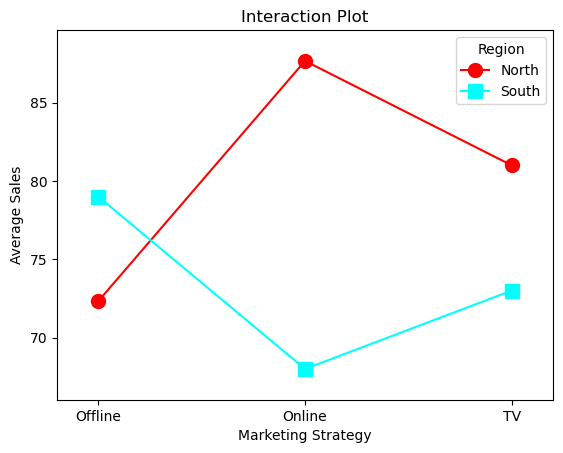

In [17]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.factorplots import interaction_plot

plt.figure(figsize=(8,5))

interaction_plot(
    sales["Marketing"],
    sales["Region"],
    sales["Sales"],
    markers=["o", "s"],
    ms=10
)

plt.title("Interaction Plot")
plt.xlabel("Marketing Strategy")
plt.ylabel("Average Sales")

plt.show()

### Interpretation of Interaction Plot
    Parallel Lines
        • No interaction exists.

    Crossing Lines
        • Interaction exists.

    The greater the distance between the lines, the stronger the interaction effect.